# Content Based Filtering (CBF)

Implementamos como método de técnica de recomendación *extra*, el algorítmo de **Content‑Based Filtering (CBF)**.
La idea es representar cada receta mediante su **contenido** (nombre, tags, ingredientes y descripción) usando **TF‑IDF**, construir un **perfil de usuario** agregando las recetas que le han gustado en *train*, y finalmente recomendar nuevas recetas por **similitud coseno** entre el perfil del usuario y los ítems.

Al final evaluamos el ranking con métricas **Precision@N, Recall@N, F1@N y nDCG@N** (en un subconjunto de usuarios para controlar el coste computacional).

**Autores:** Gallo Álvaro, García Álvaro, Recover Diego, Rízquez Tello

> Nota: Para obtener más información sobre el proyecto puedes consultar el repositorio original en [GitHub](https://github.com/DiegoRecover8/Food.com-Recommender-Systems).


In [139]:
# Librerías utilizadas

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

In [140]:
# Cargamos los datos
recipes = pd.read_csv("../data/processed/recipes_clean.csv")
train = pd.read_csv("../data/processed/interactions_train_clean.csv")
test  = pd.read_csv("../data/processed/interactions_test_clean.csv")

In [141]:
# Definimos las constantes conocidas

NUM_ITEMS = int(max(train["i"].max(), test["i"].max())) + 1
NUM_USERS = int(max(train["u"].max(), test["u"].max())) + 1

MAX_USERS_EVAL = 200  # limita usuarios para evaluación  
MAX_FEATURES =   200000  # TF-IDF vocab size
MIN_DF = 2            # guardamos palabras que aparecen en al menos en 2 recetas
MAX_DF = 0.9          # guardamos palabras que aparecen en menos del 90% de las recetas

## Preparación del contenido de los ítems

Para aplicar CBF necesitamos una representación vectorial de cada receta (*item*).  
Primero creamos un **mapeo** entre el índice interno `i` (usado en las interacciones) y el `recipe_id` real, y lo unimos con `recipes_clean.csv` para obtener la información textual (name, tags, ingredients, description).

Después construimos un campo `text` por receta y lo normalizamos (minúsculas, eliminación de corchetes/comillas típicas de listas).


In [142]:
# Map i <-> recipe_id y construir índice de items (i)
item_map = train[["i", "recipe_id"]].drop_duplicates().copy()
item_map["i"] = item_map["i"].astype(int)
item_map["recipe_id"] = item_map["recipe_id"].astype(int)

# Merge recipes con mapping (recipes.id es el recipe_id)
recipes = recipes.rename(columns={"id": "recipe_id"})
recipes["recipe_id"] = recipes["recipe_id"].astype(int)

items_df = item_map.merge(recipes, on="recipe_id", how="left")

# Si hay recipe_id en interacciones que no están en recipes_clean, quedarían NaN
missing = items_df["name"].isna().sum()
print(f"Items sin metadata en recipes_clean: {missing} / {len(items_df)}")
# Rellenamos NaNs para que TF-IDF no falle
for col in ["name", "tags", "ingredients", "description", "steps"]:
    if col in items_df.columns:
        items_df[col] = items_df[col].fillna("")

# Normalizamos texto pasamos a minúsculas, quitamos corchetes, comillas, etc.
def normalize_list_string(s):
    s = str(s)
    s = s.lower()
    # quitar corchetes y comillas típicas de listas
    s = re.sub(r"[\[\]\(\)\{\}\'\"]", " ", s)
    s = s.replace(",", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def build_text_row(row):
    parts = []
    if "name" in row:        parts.append(normalize_list_string(row["name"]))
    if "tags" in row:        parts.append(normalize_list_string(row["tags"]))
    if "ingredients" in row: parts.append(normalize_list_string(row["ingredients"]))
    # if "description" in row: parts.append(normalize_list_string(row["description"]))
    return " ".join([p for p in parts if p])

items_df["text"] = items_df.apply(build_text_row, axis=1)

# TF-IDF items matrix: X_items (NUM_ITEMS x vocab)
# Creamos una serie de textos de longitud NUM_ITEMS (rellenando lo que falte)
texts = [""] * NUM_ITEMS
for _, r in items_df.iterrows():
    ii = int(r["i"])
    texts[ii] = r["text"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES,
)

X_items = vectorizer.fit_transform(texts)  # csr (NUM_ITEMS x vocab)
X_items = normalize(X_items, norm="l2", axis=1)  # para coseno vía producto escalar
print("X_items:", X_items.shape, "nnz:", X_items.nnz)

# Construir perfiles de usuario (user_profiles)
# Perfil = media (o suma) de TF-IDF de ítems positivos del usuario en train

# Filtramos positivos
train_pos = train[train["rating"] >= theta].copy()
train_pos["u"] = train_pos["u"].astype(int)
train_pos["i"] = train_pos["i"].astype(int)

# Matriz usuario-item positivo
# Aquí usamos pesos=1.0 para simplicidad  
pos_mat = csr_matrix(
    (train_pos["rating"].astype(float).values,
     (train_pos["u"].astype(int).values, train_pos["i"].astype(int).values)),
    shape=(NUM_USERS, NUM_ITEMS)
)

user_profiles = normalize(pos_mat @ X_items, norm="l2", axis=1)


print("user_profiles:", user_profiles.shape)

# También necesitaremos "seen items" (ítems ya vistos por usuario en train)
train_seen = csr_matrix(
    (np.ones(len(train), dtype=np.int8),
     (train["u"].astype(int).values, train["i"].astype(int).values)),
    shape=(NUM_USERS, NUM_ITEMS)
)

# Construir matriz de ratings de test para evaluación posterior
ratings = csr_matrix(
    (test["rating"].astype(float).values,
     (test["u"].astype(int).values, test["i"].astype(int).values)),
    shape=(NUM_USERS, NUM_ITEMS)
)

Items sin metadata en recipes_clean: 0 / 160901
X_items: (178265, 10595) nnz: 6235297
user_profiles: (25076, 10595)


## Ejemplo de recomendaciones y explicación

Antes de evaluar el sistema mostramos un ejemplo cualitativo:  
- Top‑N recomendaciones para un usuario concreto (con su *score* de similitud).  
- Un gráfico sencillo de los scores.  
- Qué recetas del historial del usuario son más similares a cada recomendación.


In [143]:
# Lookup para mostrar títulos
lookup = items_df.set_index("i")[["recipe_id", "name"]]

def recommend_user_with_scores(u, N=10):
    scores = (user_profiles.getrow(u) @ X_items.T).toarray().ravel()
    seen_items = train_seen.getrow(u).indices
    scores[seen_items] = -np.inf

    top_idx = np.argpartition(scores, -N)[-N:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    top_scores = scores[top_idx]
    return top_idx.tolist(), top_scores.tolist()

u_example = int(train_pos["u"].iloc[0])  # o elige uno a mano
recs, rec_scores = recommend_user_with_scores(u_example, N=10)

rows = []
for rank, (ii, sc) in enumerate(zip(recs, rec_scores), 1):
    if ii in lookup.index:
        rid = int(lookup.loc[ii, "recipe_id"])
        nm = str(lookup.loc[ii, "name"])
    else:
        rid, nm = None, f"item {ii}"
    rows.append({"rank": rank, "i": ii, "recipe_id": rid, "name": nm, "score": sc})

df_recs = pd.DataFrame(rows)
df_recs

,rank,i,recipe_id,name,score
0,1,47096,35087,parmesan onion bake,0.594670
1,2,53205,79281,najwa s chicken soup,0.583382
2,3,3363,24515,crisp garlic potato skins,0.580503
3,4,154785,19129,baked celery,0.578596
4,5,107689,79498,salsa chicken with cheese,0.576733
5,6,36314,33392,hump day vegetables,0.574104
6,7,145289,56376,baked tomato,0.574082
7,8,95988,120717,bartolino s marinara sauce,0.570690
8,9,127741,10837,fresh tomato spaghetti sauce,0.568204
9,10,149057,341023,stuffed baby red potatoes,0.564186


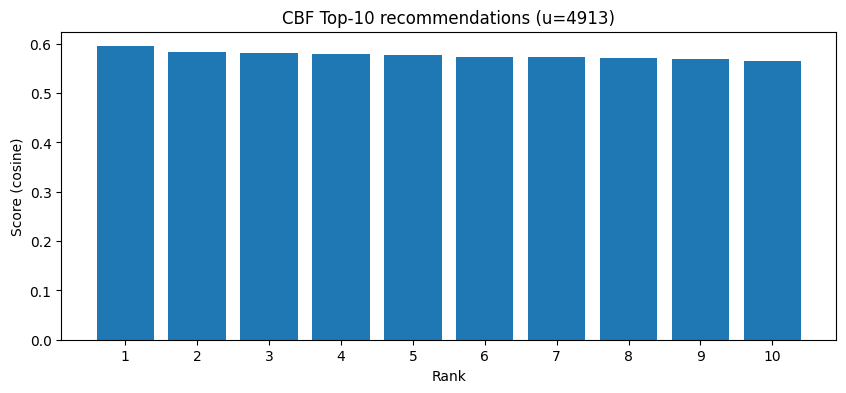

In [144]:
plt.figure(figsize=(10,4))
plt.bar(df_recs["rank"], df_recs["score"])
plt.xticks(df_recs["rank"])
plt.xlabel("Rank")
plt.ylabel("Score (cosine)")
plt.title(f"CBF Top-{len(df_recs)} recommendations (u={u_example})")
plt.show()

In [145]:
# Recetas positivas en train para ese usuario
user_train_pos = train_pos[train_pos["u"] == u_example].copy()
user_train_pos = user_train_pos.sort_values("rating", ascending=False).head(10)

hist_rows = []
for _, r in user_train_pos.iterrows():
    ii = int(r["i"])
    rating = float(r["rating"])
    if ii in lookup.index:
        rid = int(lookup.loc[ii, "recipe_id"])
        nm = str(lookup.loc[ii, "name"])
    else:
        rid, nm = None, f"item {ii}"
    hist_rows.append({"i": ii, "recipe_id": rid, "name": nm, "rating": rating})

df_hist = pd.DataFrame(hist_rows)
df_hist

,i,recipe_id,name,rating
0,10489,2137,fresh rhubarb pie,5.0
1,114402,46877,uncle bill s whipped shortbread cookies,5.0
2,178090,63869,cubano chicken with spicy currant picadillo,5.0
3,11926,59135,husband s delight,5.0
4,17138,58923,honey glazed onions,5.0
5,32722,57549,cinnamon roll toast,5.0
6,21924,57283,stuffed onions crock pot,5.0
7,9416,56096,grilled lime marinated flank steak with chipot...,5.0
8,106279,54632,creamy easy brussels sprouts soup,5.0
9,136571,52077,spicy banana fritters zitumbuwa,5.0


## Umbral de relevancia y top‑N para ranking

Utilizamos un umbral `theta=4` sobre las valoraciones reales, es decir, un ítem se considera relevante si el usuario lo ha puntuado con $4$ o más estrellas. Además, se fija `N=10` como longitud del ranking para evaluar las métricas de precisión y recall. Con estos valores podemos calcular, para cada usuario, cuántas de sus recetas relevantes aparecen entre las diez mejores recomendaciones y qué proporción de las recomendaciones son relevantes.

### Construcción de `preds_dict`

Para reutilizar las funciones de evaluación de los notebooks anteriores, guardamos las predicciones en un diccionario:

- **clave**: `(u, i)` (usuario e ítem en índices internos),
- **valor**: `score` (similitud coseno entre el perfil del usuario y el vector TF‑IDF del ítem).

Como el número de ítems es muy grande, no calculamos scores para todos los ítems. En su lugar:
1. Calculamos el score para todos los ítems de forma vectorizada.
2. Excluimos los ítems ya vistos por el usuario en *train*.
3. Guardamos solo los **Top‑M** ítems con mayor score (por defecto `TOP_M=100`) para cada usuario evaluado.

In [146]:
theta = 4
N = 10  # Top-N

In [147]:
TOP_M = 100  # guarda top-100 por usuario (debe ser >= N)

# Usuarios a evaluar: los que tienen al menos 1 interacción en test
test_rel_users = test.loc[test["rating"] >= theta, "u"].astype(int).unique()
test_users_all = np.unique(ratings.nonzero()[0])

# Limitamos por coste computacional y fijamos semilla
eligible = np.intersect1d(test_users_all, test_rel_users)
np.random.seed(42)
test_users = np.random.choice(eligible, size=min(MAX_USERS_EVAL, len(eligible)), replace=False)

preds_dict = {}

for u in test_users:
    u = int(u)

    # scores = cos(profile_u, item_vec)
    scores = (user_profiles.getrow(u) @ X_items.T).toarray().ravel()

    # excluir vistos en train
    seen_items = train_seen.getrow(u).indices
    scores[seen_items] = -np.inf

    # si no tiene perfil útil, saltar
    if np.all(np.isneginf(scores)):
        continue

    # top-M eficiente
    top_idx = np.argpartition(scores, -TOP_M)[-TOP_M:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]

    for i in top_idx:
        preds_dict[(u, int(i))] = float(scores[int(i)])

print("preds_dict size:", len(preds_dict))
print("test_users eval:", len(test_users))

preds_dict size: 20000
test_users eval: 200


In [148]:
def get_user_precision(u, preds_dict, ratings, N=10, theta=4):
    row = ratings.getrow(u)
    test_items = row.indices
    test_ratings = row.data
    if test_items.size == 0:
        return None

    # Relevantes en test
    relevant = {int(i) for i, r in zip(test_items, test_ratings) if float(r) >= theta}
    if len(relevant) == 0:
        return None

    preds_u = [(i, p) for (uu, i), p in preds_dict.items() if uu == u and p is not None]
    if len(preds_u) == 0:
        return None

    preds_u.sort(key=lambda x: x[1], reverse=True)
    topN_items = [int(i) for i, _ in preds_u[:N]]

    hits = sum(1 for i in topN_items if i in relevant)
    return hits / N

In [149]:
def get_precision(preds_dict, ratings, users_subset, N=10, theta=4):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        up = get_user_precision(u, preds_dict, ratings, N=N, theta=theta)
        if up is not None:
            acc += up
            count += 1

    return (acc / count) if count > 0 else None

In [150]:
precision  = get_precision(preds_dict,  ratings, test_users, N=N, theta=theta)
print("CBF Precision = {precision}".format(N=N, precision=precision))

CBF Precision = 0.0


## Métrica Recall@N

La función `get_user_recall` implementa el cálculo del recall para un usuario concreto. En primer lugar identifica los ítems relevantes del conjunto de test (aquellos con puntuación real mayor o igual que `theta`). A continuación ordena todas las predicciones disponibles para ese usuario, selecciona las $N$ con mayor puntuación y calcula qué fracción de los ítems relevantes están presentes en ese top‑N. Un valor de recall cercano a 1 indica que el sistema recupera la mayoría de los ítems que realmente interesan al usuario, aunque no tenga en cuenta la proporción de irrelevantes.


In [151]:
def get_user_recall(u, preds_dict, ratings, N=10, theta=4):
    row = ratings.getrow(u)
    test_items = row.indices
    test_ratings = row.data

    if test_items.size == 0:
        return None

    # Conjunto de relevantes en TEST
    relevant = {int(i) for i, r in zip(test_items, test_ratings) if float(r) >= theta}
    if len(relevant) == 0:
        return None  # no hay "positivos" para este usuario

    # Candidatos recomendables = ítems para los que tenemos predicción para u
    preds_u = [(i, p) for (uu, i), p in preds_dict.items() if uu == u and p is not None]
    if len(preds_u) == 0:
        return None

    # Top-N recomendados
    preds_u.sort(key=lambda x: x[1], reverse=True)
    recommended = {int(i) for i, _ in preds_u[:N]}

    hits = len(relevant & recommended)
    return hits / len(relevant)

In [152]:
def get_recall(preds_dict, ratings, users_subset, N=10, theta=4):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        ur = get_user_recall(u, preds_dict, ratings, N=N, theta=theta)
        if ur is not None:
            acc += ur
            count += 1

    return (acc / count) if count > 0 else None

In [153]:
recall = get_recall(preds_dict,  ratings, test_users, N=N, theta=theta)
print(f"Recall = {recall}")

Recall = 0.0


## F1 como medida combinada de precisión y recall

La precisión y el recall evalúan aspectos complementarios de las recomendaciones. La precisión mide la proporción de aciertos dentro del top‑N, mientras que el recall mide la cobertura sobre todos los ítems relevantes. La función `get_user_f1` combina ambas mediante la media armónica (F1). Si alguna de las métricas es nula, devuelve `None`; si ambas son cero, devuelve $0$. Este equilibrio penaliza sistemas que sacrifican excesivamente una métrica en beneficio de la otra y permite comparar modelos cuando se desea maximizar simultáneamente precisión y recall.


In [154]:
def get_user_f1(u, preds_dict, ratings, N=10, theta=4):
    precision = get_user_precision(u, preds_dict, ratings, N=N, theta=theta)
    recall = get_user_recall(u, preds_dict, ratings, N=N, theta=theta)

    if precision is None or recall is None:
        return None
    elif precision == 0 and recall == 0:
        return 0.0
    else:
        return 2 * precision * recall / (precision + recall)

In [155]:
def get_f1(preds_dict, ratings, users_subset, N=10, theta=4):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        uf1 = get_user_f1(u, preds_dict, ratings, N=N, theta=theta)
        if uf1 is not None:
            acc += uf1
            count += 1

    return (acc / count) if count > 0 else None

In [156]:
f1  = get_f1(preds_dict,  ratings, test_users, N=N, theta=theta)
print(f"F1 = {f1}")

F1 = 0.0


## Ganancia acumulada descontada ideal (IDCG)

Para evaluar la calidad de un ranking también se utilizan métricas basadas en la posición de los ítems relevantes. La función `get_user_idcg` calcula la ganancia acumulada descontada ideal (IDCG) para un usuario. Ordena sus valoraciones reales de mayor a menor, toma las $N$ primeras y suma $\frac{2^{r} - 1}{\log_2(\text{posición}+1)}$ para cada una. Este valor representa el máximo DCG que podríamos obtener si las recomendaciones estuvieran perfectamente ordenadas según la relevancia, y se emplea para normalizar el DCG calculado a partir de las predicciones obteniendo el NDCG, que permite comparar rankings de distinta longitud y usuarios con distintos números de ítems relevantes.


In [157]:
def get_user_idcg(u, ratings, N=10):
    row = ratings.getrow(u)
    items = row.indices
    ratings2 = row.data

    if items.size == 0:
        return None

    # Orden ideal por rating real descendente
    order = np.argsort(ratings2)[::-1]
    items_sorted = items[order][:N]
    ratings_sorted = ratings2[order][:N]

    idcg = 0.0
    for pos, r in enumerate(ratings_sorted):
        idcg += (2 ** float(r) - 1) / math.log(pos + 2, 2)

    return idcg

In [158]:
def get_user_dcg(u, recommended_items, ratings, N=10):
    row = ratings.getrow(u)
    items = row.indices
    ratings2 = row.data

    if items.size == 0:
        return None

    # Mapa item -> rating real en test
    true_map = {int(i): float(r) for i, r in zip(items, ratings2)}

    dcg = 0.0
    for pos, i in enumerate(recommended_items[:N]):
        if i is None:
            continue
        i = int(i)
        if i in true_map:
            r = true_map[i]
            dcg += (2 ** r - 1) / math.log(pos + 2, 2)

    return dcg

In [159]:
def get_user_ndcg(u, preds_dict, ratings, N=10):
    # Obtener ítems recomendados (Top-N por predicción)
    preds_u = [(i, p) for (uu, i), p in preds_dict.items() if uu == u and p is not None]
    if len(preds_u) == 0:
        return None

    preds_u.sort(key=lambda x: x[1], reverse=True)
    recommended_items = [int(i) for i, _ in preds_u[:N]]

    dcg = get_user_dcg(u, recommended_items, ratings, N=N)
    idcg = get_user_idcg(u, ratings, N=N)

    if idcg is None or idcg == 0:
        return 0.0
    return dcg / idcg

In [160]:
def get_ndcg(preds_dict, ratings, users_subset, N=10):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        undcg = get_user_ndcg(u, preds_dict, ratings, N=N)
        if undcg is not None:
            acc += undcg
            count += 1

    return (acc / count) if count > 0 else None

In [161]:
ndcg = get_ndcg(preds_dict,  ratings, test_users, N=N)
print(f"nDCG Avg Prediction with Corr Similarity = {ndcg:.4f}")

nDCG Avg Prediction with Corr Similarity = 0.0000


## Conclusión e interpretación de resultados (CBF)

Al evaluar el modelo con el conjunto de *test* (con umbrales como $\theta=3/4$ y $N=10/20$), **todas las métricas han dado 0.0** (Precision@N, Recall@N, F1@N, nDCG@N). 

Esto sugiere que, en este dataset y particionado concreto, el contenido textual disponible no está siendo suficiente para “recuperar” el ítem objetivo del test en el ranking, incluso tras probar ajustes razonables como ponderar el perfil por rating, limitar el texto a tags+ ingredients y relajar/ajustar los parámetros de TF-IDF (min_df/max_df/max_features). En otras palabras, el modelo sí es capaz de generar recomendaciones (perfiles no vacíos y scores calculables), pero **no coincide con los ítems del test**, por lo que el rendimiento medido es nulo.

Una interpretación plausible es que Food.com tiene un comportamiento muy marcado por señales **colaborativas** (popularidad, co-consumo, patrones latentes) que CBF no capta bien solo con texto, o que el propio protocolo de evaluación (muy “leave-one-out” por usuario y con un objetivo único en test) hace que acertar sea extremadamente difícil si no se explotan señales colaborativas. Por eso, frente a KNN/MF/Bernoulli MF, CBF queda como una técnica extra interesante por su enfoque y por cómo aborda el *cold-start* de ítems, pero en este caso concreto **no aporta mejora medible** en las métricas de ranking evaluadas.